<a href="https://colab.research.google.com/github/Fardous-bp/CNS-doped-Al-interconnect-alloy/blob/main/CNS_Al_12_5_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install matcalc

!pip install matgl
!pip install seekpath

!pip install crystal-toolkit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 579.9/579.9 kB 27.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.4/596.4 kB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 778.8/778.8 kB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.1/829.1 kB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 804.2/804.2 kB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 100.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.6/106.6 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os
from pymatgen.core import Structure
my_cif_file = "CuNi2Sn.cif"

if os.path.exists(my_cif_file):
    my_structure = Structure.from_file(my_cif_file)
    print(f"SUCCESS: {my_cif_file} loaded successfully.")
    print(my_structure)
else:
    print(f"ERROR: File '{my_cif_file}' not found. Please check the name in your Colab files tab.")

SUCCESS: CuNi2Sn.cif loaded successfully.
Full Formula (Cu4 Ni8 Sn4)
Reduced Formula: CuNi2Sn
abc   :   5.975124   5.975124   5.975124
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (16)
  #  SP       a     b     c
---  ----  ----  ----  ----
  0  Cu    0     0     0
  1  Cu    0     0.5   0.5
  2  Cu    0.5   0     0.5
  3  Cu    0.5   0.5   0
  4  Ni    0.25  0.75  0.75
  5  Ni    0.25  0.25  0.75
  6  Ni    0.25  0.25  0.25
  7  Ni    0.25  0.75  0.25
  8  Ni    0.75  0.75  0.25
  9  Ni    0.75  0.25  0.25
 10  Ni    0.75  0.25  0.75
 11  Ni    0.75  0.75  0.75
 12  Sn    0     0     0.5
 13  Sn    0     0.5   0
 14  Sn    0.5   0     0
 15  Sn    0.5   0.5   0.5


In [ ]:
# The value 0.2 adds random noise (in Angstroms) to the atomic sites
cuni2sn_perturbed = my_structure.copy()
cuni2sn_perturbed.perturb(0.2)

# 2. Expand the lattice volume
# Multiplying by 1.2 increases the total cell volume by 20%
cuni2sn_perturbed.scale_lattice(my_structure.volume * 1.2)

# 3. View the results
print("Perturbed CuNi2Sn Structure:")
print(cuni2sn_perturbed)
cuni2sn_perturbed

Perturbed CuNi2Sn Structure:
Full Formula (Cu4 Ni8 Sn4)
Reduced Formula: CuNi2Sn
abc   :   6.349517   6.349517   6.349517
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (16)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  Cu    0.995021  0.990939  0.003354
  1  Cu    0.015969  0.486523  0.51293
  2  Cu    0.503118  0.985271  0.49037
  3  Cu    0.479984  0.486997  0.988718
  4  Ni    0.247972  0.747981  0.752853
  5  Ni    0.249804  0.248472  0.753071
  6  Ni    0.256382  0.243432  0.257234
  7  Ni    0.238732  0.778066  0.238806
  8  Ni    0.753829  0.751325  0.242214
  9  Ni    0.731642  0.244771  0.267334
 10  Ni    0.751737  0.24707   0.737815
 11  Ni    0.760262  0.770806  0.750224
 12  Sn    0.975577  0.989038  0.51145
 13  Sn    0.997669  0.498675  0.998445
 14  Sn    0.501914  0.994134  0.992598
 15  Sn    0.521084  0.492486  0.519011


Structure Summary
Lattice
    abc : 6.349516720528679 6.349516720528679 6.349516720528679
 angles : 90.0 90.0 90.0
 volume : 255.98941833973996
      A : 6.349516720528679 0.0 3.887957663964023e-16
      B : 1.0210801652782683e-15 6.349516720528679 3.887957663964023e-16
      C : 0.0 0.0 6.349516720528679
    pbc : True True True
PeriodicSite: Cu0 (Cu) (6.318, 6.292, 0.02129) [0.995, 0.9909, 0.003354]
PeriodicSite: Cu1 (Cu) (0.1014, 3.089, 3.257) [0.01597, 0.4865, 0.5129]
PeriodicSite: Cu2 (Cu) (3.195, 6.256, 3.114) [0.5031, 0.9853, 0.4904]
PeriodicSite: Cu3 (Cu) (3.048, 3.092, 6.278) [0.48, 0.487, 0.9887]
PeriodicSite: Ni4 (Ni) (1.575, 4.749, 4.78) [0.248, 0.748, 0.7529]
PeriodicSite: Ni5 (Ni) (1.586, 1.578, 4.782) [0.2498, 0.2485, 0.7531]
PeriodicSite: Ni6 (Ni) (1.628, 1.546, 1.633) [0.2564, 0.2434, 0.2572]
PeriodicSite: Ni7 (Ni) (1.516, 4.94, 1.516) [0.2387, 0.7781, 0.2388]
PeriodicSite: Ni8 (Ni) (4.786, 4.771, 1.538) [0.7538, 0.7513, 0.2422]
PeriodicSite: Ni9 (Ni) (4.646, 1.554, 1.

In [ ]:
import matcalc
from matcalc.utils import UNIVERSAL_CALCULATORS

import pprint
pprint.pprint(list(UNIVERSAL_CALCULATORS))  # calculators that come with bundled with matgl

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


[<UNIVERSAL_CALCULATORS.CHGNet-MatPES-PBE-2025.2.10: 'CHGNet-MatPES-PBE-2025.2.10'>,
 <UNIVERSAL_CALCULATORS.CHGNet-MatPES-r2SCAN-2025.2.10: 'CHGNet-MatPES-r2SCAN-2025.2.10'>,
 <UNIVERSAL_CALCULATORS.DPA3-LAM-2025.3.14: 'DPA3-LAM-2025.3.14'>,
 <UNIVERSAL_CALCULATORS.GRACE-1L-OAM: 'GRACE-1L-OAM'>,
 <UNIVERSAL_CALCULATORS.GRACE-2L-MPtrj: 'GRACE-2L-MPtrj'>,
 <UNIVERSAL_CALCULATORS.GRACE-2L-OAM: 'GRACE-2L-OAM'>,
 <UNIVERSAL_CALCULATORS.GRACE-2L-OMAT: 'GRACE-2L-OMAT'>,
 <UNIVERSAL_CALCULATORS.M3GNet-MatPES-PBE-2025.1: 'M3GNet-MatPES-PBE-2025.1'>,
 <UNIVERSAL_CALCULATORS.MACE-MP-0-large: 'MACE-MP-0-large'>,
 <UNIVERSAL_CALCULATORS.MACE-MP-0-medium: 'MACE-MP-0-medium'>,
 <UNIVERSAL_CALCULATORS.MACE-MP-0-small: 'MACE-MP-0-small'>,
 <UNIVERSAL_CALCULATORS.MACE-MP-0b-medium: 'MACE-MP-0b-medium'>,
 <UNIVERSAL_CALCULATORS.MACE-MP-0b-small: 'MACE-MP-0b-small'>,
 <UNIVERSAL_CALCULATORS.MACE-MP-0b2-large: 'MACE-MP-0b2-large'>,
 <UNIVERSAL_CALCULATORS.MACE-MP-0b2-medium: 'MACE-MP-0b2-medium'>,
 <UNIVE

In [ ]:
from matcalc.utils import MODEL_ALIASES
pprint.pprint(MODEL_ALIASES)  # list all "aliased" models

{'chgnet': 'CHGNet-MatPES-PBE-2025.2.10',
 'chgnet-matpes-pbe-2025.2.10-2.7m-pes': 'CHGNet-MatPES-PBE-2025.2.10',
 'chgnet-pes-matpes-pbe-2025.2.10': 'CHGNet-MatPES-PBE-2025.2.10',
 'chgnet-pes-matpes-r2scan-2025.2.10': 'CHGNet-MatPES-r2SCAN-2025.2.10',
 'deepmd': 'DPA3-LAM-2025.3.14',
 'fairchem': 'UMA-S-1.2',
 'grace': 'GRACE-2L-OAM',
 'm3gnet': 'M3GNet-MatPES-PBE-2025.1',
 'm3gnet-pes-matpes-pbe-2025.1': 'M3GNet-MatPES-PBE-2025.1',
 'mace': 'MACE-MPA-0-medium',
 'mattersim': 'MatterSim-v1.0.0-1M',
 'orb': 'ORB-v2',
 'pbe': 'TensorNet-MatPES-PBE-2025.2',
 'petmad': 'PETMAD-1.0.0',
 'r2scan': 'TensorNet-MatPES-r2SCAN-2025.2',
 'sevennet': 'SevenNet-0',
 'tensornet': 'TensorNet-MatPES-PBE-2025.2',
 'tensornet-pes-matpes-pbe-2025.2': 'TensorNet-MatPES-PBE-2025.2',
 'tensornet-pes-matpes-r2scan-2025.2': 'TensorNet-MatPES-r2SCAN-2025.2',
 'tensorpotential': 'GRACE-2L-OAM',
 'uma': 'UMA-S-1.2'}


In [ ]:
calculator_pbe = matcalc.load_fp("pbe")

model.pt:   0%|          | 0.00/4.50k [00:00<?, ?B/s]

state.pt:   0%|          | 0.00/3.40M [00:00<?, ?B/s]

model.json:   0%|          | 0.00/5.30k [00:00<?, ?B/s]

In [ ]:
# Initialize the Relaxer exactly like the notebook
relax_calc = matcalc.RelaxCalc(
    calculator_pbe,
    optimizer="FIRE",
    relax_atoms=True,
    relax_cell=True,
)

# This should now complete in 1-3 minutes
print("Starting structural optimization...")
data = relax_calc.calc(cuni2sn_perturbed)

# Output results
print(f"Optimization Successful!")
print(f"Final Energy: {data['energy']:.4f} eV")
print(f"Final Optimized Volume: {data['final_structure'].volume:.2f} A^3")

Starting structural optimization...
Optimization Successful!
Final Energy: -75.9557 eV
Final Optimized Volume: 214.45 A^3


In [ ]:
pprint.pprint(data)

{'_units': {'a': 'A',
            'alpha': 'degree',
            'b': 'A',
            'beta': 'degree',
            'c': 'A',
            'energy': 'eV',
            'final_structure': Structure Summary
Lattice
    abc : 6.349516720528679 6.349516720528679 6.349516720528679
 angles : 90.0 90.0 90.0
 volume : 255.98941833973996
      A : 6.349516720528679 0.0 3.887957663964023e-16
      B : 1.0210801652782683e-15 6.349516720528679 3.887957663964023e-16
      C : 0.0 0.0 6.349516720528679
    pbc : True True True
PeriodicSite: Cu0 (Cu) (6.318, 6.292, 0.02129) [0.995, 0.9909, 0.003354]
PeriodicSite: Cu1 (Cu) (0.1014, 3.089, 3.257) [0.01597, 0.4865, 0.5129]
PeriodicSite: Cu2 (Cu) (3.195, 6.256, 3.114) [0.5031, 0.9853, 0.4904]
PeriodicSite: Cu3 (Cu) (3.048, 3.092, 6.278) [0.48, 0.487, 0.9887]
PeriodicSite: Ni4 (Ni) (1.575, 4.749, 4.78) [0.248, 0.748, 0.7529]
PeriodicSite: Ni5 (Ni) (1.586, 1.578, 4.782) [0.2498, 0.2485, 0.7531]
PeriodicSite: Ni6 (Ni) (1.628, 1.546, 1.633) [0.2564, 0.2434, 0

In [ ]:
final_structure_pbe = data["final_structure"]
print(final_structure_pbe)
final_structure_pbe

Full Formula (Cu4 Ni8 Sn4)
Reduced Formula: CuNi2Sn
abc   :   5.984803   5.985544   5.986382
angles:  90.007534  90.024793  90.042322
pbc   :       True       True       True
Sites (16)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  Cu    0.997034  1.00197   0.002641
  1  Cu    0.000296  0.497705  0.499887
  2  Cu    0.500503  0.991978  0.502139
  3  Cu    0.497273  0.496128  0.999233
  4  Ni    0.243944  0.750249  0.754609
  5  Ni    0.249855  0.244105  0.746765
  6  Ni    0.253382  0.244871  0.255299
  7  Ni    0.247428  0.749742  0.247577
  8  Ni    0.749885  0.744309  0.246763
  9  Ni    0.744103  0.250068  0.2547
 10  Ni    0.747448  0.249801  0.747522
 11  Ni    0.753303  0.744953  0.755462
 12  Sn    0.997622  0.996826  0.498703
 13  Sn    1.00084   0.490997  1.00202
 14  Sn    0.50114   0.9984    0.99971
 15  Sn    0.496645  0.503881  0.503393


Structure Summary
Lattice
    abc : 5.984803104520652 5.9855443311543635 5.986381504327345
 angles : 90.00753388594265 90.02479264485991 90.042322445066
 volume : 214.44589943278234
      A : 5.984802556506943 -0.0022099543901761974 -0.0012944533968704394
      B : -0.0022111751575755586 5.9855439097896115 -0.0003935721758048392
      C : -0.0012957375680089285 -0.0003940074626367772 5.986381351131483
    pbc : True True True
PeriodicSite: Cu (5.965, 5.995, 0.01412) [0.997, 1.002, 0.002641]
PeriodicSite: Cu (2.119e-05, 2.979, 2.992) [0.0002957, 0.4977, 0.4999]
PeriodicSite: Cu (2.993, 5.936, 3.005) [0.5005, 0.992, 0.5021]
PeriodicSite: Cu (2.974, 2.968, 5.981) [0.4973, 0.4961, 0.9992]
PeriodicSite: Ni (1.457, 4.49, 4.517) [0.2439, 0.7502, 0.7546]
PeriodicSite: Ni (1.494, 1.46, 4.47) [0.2499, 0.2441, 0.7468]
PeriodicSite: Ni (1.516, 1.465, 1.528) [0.2534, 0.2449, 0.2553]
PeriodicSite: Ni (1.479, 4.487, 1.481) [0.2474, 0.7497, 0.2476]
PeriodicSite: Ni (4.486, 4.453, 1.476) [0.7499, 0.744

In [ ]:
from matcalc import ElasticityCalc

# Use the 'final_structure_pbe' generated
multiplier_GPa = 160.2176621
elastic_calc = ElasticityCalc(calculator_pbe, relax_structure=False)
elastic_results = elastic_calc.calc(final_structure_pbe)

print(f"Bulk Modulus: {elastic_results['bulk_modulus_vrh'] * multiplier_GPa:.2f} GPa")
print(f"Shear Modulus: {elastic_results['shear_modulus_vrh'] * multiplier_GPa:.2f} GPa")

Bulk Modulus: 142.70 GPa
Shear Modulus: 37.69 GPa


/tmp/ipykernel_970/73195017.py:6: RuntimeWarning: Elastic strain-stress fits have mean R²=0.7159 below r2_min=0.95. The elastic tensor may be unreliable; consider smaller |strains|, more strain points, or enabling relax_deformed_structures.
  elastic_results = elastic_calc.calc(final_structure_pbe)


Calculating Phonon Data for Pure CuNi2Sn...


/tmp/ipykernel_970/1823654510.py:24: DeprecationWarning: get_total_dos_dict() is deprecated. Use the total_dos property to access the TotalDos result object; its frequency_points and dos attributes replace the dict keys.
  dos_dict = ph.get_total_dos_dict()


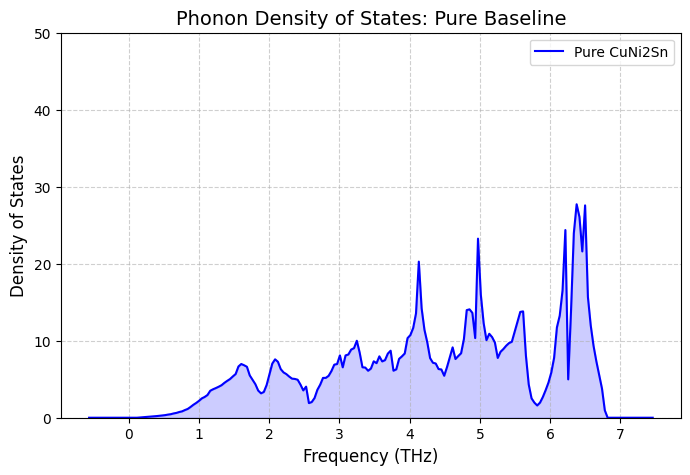

In [ ]:
from matcalc import PhononCalc
import matplotlib.pyplot as plt

# 1. Initialize for the pure structure
phonon_calc = PhononCalc(
    calculator_pbe,
    supercell_matrix=((2, 0, 0), (0, 2, 0), (0, 0, 2)),
    relax_structure=False
)

print("Calculating Phonon Data for Pure CuNi2Sn...")
pure_phonon_data = phonon_calc.calc(final_structure_pbe)

# 2. Access the Phonopy object
ph = pure_phonon_data["phonon"]

# 3. Trigger the DOS calculation (Fixes the AttributeError)
# We use a mesh of 20x20x20 for resolution
ph.run_mesh([20, 20, 20])
ph.run_total_dos()

# 4. Extract frequencies and densities
# get_total_dos_dict() returns a dictionary with 'frequency-points' and 'total-dos'
dos_dict = ph.get_total_dos_dict()
freqs = dos_dict['frequency_points']
densities = dos_dict['total_dos']

# 5. Visualization for Paper
plt.figure(figsize=(8, 5))
plt.plot(freqs, densities, color='blue', label='Pure CuNi2Sn')
plt.fill_between(freqs, densities, color='blue', alpha=0.2)
plt.ylim(0, 50)
plt.title("Phonon Density of States: Pure Baseline", fontsize=14)
plt.xlabel("Frequency (THz)", fontsize=12)
plt.ylabel("Density of States", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# 1. Second 'Doped' version from the pure optimized structure
sac_al_12_5 = final_structure_pbe.copy()

# 2. Replace TWO sites with Aluminum to achieve 12.5% doping (2/16 atoms)
# We use site 12 (Sn) and site 0 (Cu) for a balanced distribution
sac_al_12_5.replace(12, "Al")
sac_al_12_5.replace(0, "Al")

print(f"Created 12.5% Al-doped structure: {sac_al_12_5.formula}")

# 3. Proceed to High-Precision Relaxation
print("Starting high-precision optimization for 12.5% Al...")
relax_results_12_5 = relax_calc.calc(sac_al_12_5)
opt_struct_12_5 = relax_results_12_5["final_structure"]

print(f"12.5% Optimized Energy: {relax_results_12_5['energy']:.4f} eV")

# 4. Calculate Elastic Moduli
elastic_results_12_5 = elastic_calc.calc(opt_struct_12_5)
multiplier_GPa = 160.2176621

bulk_12_5 = elastic_results_12_5['bulk_modulus_vrh'] * multiplier_GPa
shear_12_5 = elastic_results_12_5['shear_modulus_vrh'] * multiplier_GPa

print(f"--- 12.5% Al Doping Results ---")
print(f"Bulk Modulus: {bulk_12_5:.2f} GPa")
print(f"Shear Modulus: {shear_12_5:.2f} GPa")

Created 12.5% Al-doped structure: Al2 Cu3 Ni8 Sn3
Starting high-precision optimization for 12.5% Al...
12.5% Optimized Energy: -77.7089 eV
--- 12.5% Al Doping Results ---
Bulk Modulus: 136.55 GPa
Shear Modulus: 43.36 GPa


/tmp/ipykernel_970/297508440.py:19: RuntimeWarning: Elastic strain-stress fits have mean R²=0.7034 below r2_min=0.95. The elastic tensor may be unreliable; consider smaller |strains|, more strain points, or enabling relax_deformed_structures.
  elastic_results_12_5 = elastic_calc.calc(opt_struct_12_5)


/usr/local/lib/python3.12/dist-packages/matcalc/_phonon.py:214: PrimitiveMatrixAutoDefaultWarning: primitive_matrix defaulted to 'auto' and was resolved to a non-identity matrix:
  [ 0.00000,  1.00000,  0.00000]
  [-0.00000, -0.00000,  1.00000]
  [ 1.00000,  0.00000,  0.00000]
This differs from phonopy v3, whose default was the identity matrix. Pass primitive_matrix='P' (or --pa P on the command line) to restore the v3 behaviour.
  phonon = phonopy.Phonopy(cell, supercell_matrix=supercell_matrix, symprec=self.symprec, primitive_matrix="auto")


Calculating Phonon Data for 12.5% Al-Doped structure...


/tmp/ipykernel_970/1459734092.py:21: DeprecationWarning: get_total_dos_dict() is deprecated. Use the total_dos property to access the TotalDos result object; its frequency_points and dos attributes replace the dict keys.
  dos_dict_12_5 = ph_12_5.get_total_dos_dict()


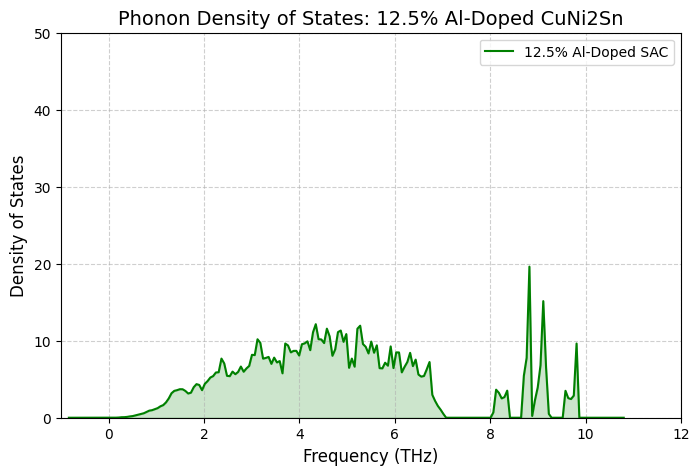

In [ ]:
from matcalc import PhononCalc
import matplotlib.pyplot as plt
import numpy as np

# 1. Initialize Phonon Calculator for 12.5%
# Using the same supercell settings for a fair comparison
phonon_calc_12_5 = PhononCalc(
    calculator_pbe,
    supercell_matrix=((2, 0, 0), (0, 2, 0), (0, 0, 2)),
    relax_structure=False
)

print("Calculating Phonon Data for 12.5% Al-Doped structure...")
phonon_data_12_5 = phonon_calc_12_5.calc(opt_struct_12_5)
ph_12_5 = phonon_data_12_5["phonon"]

# 2. Run high-resolution DOS
ph_12_5.run_mesh([20, 20, 20])
ph_12_5.run_total_dos()

dos_dict_12_5 = ph_12_5.get_total_dos_dict()
freqs_12_5 = dos_dict_12_5['frequency_points']
densities_12_5 = dos_dict_12_5['total_dos']

# 3. Visualization
plt.figure(figsize=(8, 5))
plt.plot(freqs_12_5, densities_12_5, color='green', label='12.5% Al-Doped SAC')
plt.fill_between(freqs_12_5, densities_12_5, color='green', alpha=0.2)

# Set Y-axis range to 0-50 for consistent comparison
plt.ylim(0, 50)
plt.xlim(-1, 12)

plt.title("Phonon Density of States: 12.5% Al-Doped CuNi2Sn", fontsize=14)
plt.xlabel("Frequency (THz)", fontsize=12)
plt.ylabel("Density of States", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [ ]:
# 4. Extract Thermodynamic Stability at Harsh Environment (473K)
ph_12_5.run_thermal_properties(t_step=5, t_max=600, t_min=0)
tp_12_5 = ph_12_5.get_thermal_properties_dict()

num_atoms = 16

# Use np to find the index closest to your target temperature (473K)
idx_473 = (np.abs(tp_12_5['temperatures'] - 473)).argmin()

# Apply the normalization factor to the target indexed outputs
normalized_free_energy = tp_12_5['free_energy'][idx_473] / num_atoms
normalized_entropy = tp_12_5['entropy'][idx_473] / num_atoms

print(f"--- 12.5% Al THERMODYNAMICS (NORMALIZED PER ATOM) ---")
print(f"Free Energy at 473K: {normalized_free_energy:.4f} kJ/mol·atom")
print(f"Entropy at 473K: {normalized_entropy:.4f} J/K/mol·atom")

--- 12.5% Al THERMODYNAMICS (NORMALIZED PER ATOM) ---
Free Energy at 473K: -9.6212 kJ/mol·atom
Entropy at 473K: 45.7816 J/K/mol·atom


/tmp/ipykernel_970/1775560834.py:3: DeprecationWarning: get_thermal_properties_dict() is deprecated. Use the thermal_properties property to access the ThermalProperties result object; its temperatures, free_energy, entropy, and heat_capacity attributes replace the dict keys.
  tp_12_5 = ph_12_5.get_thermal_properties_dict()
